# Fitting a 2D Gaussian Using DeepTrack and PyTorch Gradients

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This tutorial demonstrates how to use DeepTrack2's integration with PyTorch for automatic differentiation. It defines a simple image generation pipeline using DeepTrack features and then use PyTorch's optimizers to fit the parameters of this pipeline to a target image.

In [2]:
import deeptrack as dt

## 1. Setting the Backend to PyTorch

First, import `xp`, which provides backend-agnostic numpy-like functions (e.g., torch.exp or np.exp) ...

In [3]:
from deeptrack.backend import xp

... then set the backend to PyTorch to enable gradient computation.

In [4]:
config = dt.backend.config
config.set_backend("torch")

## 2. Defining Custom DeepTrack Features

You will now define two custom features:
* `Gaussian2d` to create a 2D Gaussian distribution.
* `Grid2d` to create the coordinate grid needed for the Gaussian calculation.

Note the use of `xp` for array operations, ensuring compatibility with the chosen backend (PyTorch in this case).

In [5]:
class Gaussian2d(dt.Feature):
    """Generate a 2D Gaussian distribution on a grid."""

    def __init__(self, sigma=(1, 1), mu=(0, 0), amplitude=1):
        super().__init__(sigma=sigma, mu=mu, amplitude=amplitude)

    def get(self, xygrid, sigma, mu, amplitude, **kwargs):
        exponent_x = (xygrid[0] - mu[0]) ** 2 / (2 * sigma[0] ** 2)
        exponent_y = (xygrid[1] - mu[1]) ** 2 / (2 * sigma[1] ** 2)
        return amplitude * xp.exp(-(exponent_x + exponent_y))

In [6]:
class Grid2d(dt.Feature):
    """Generate a 2D coordinate grid."""

    __distributed__ = False # Optional: Hint for distributed execution

    def __init__(self, shape=(64, 64), xlim=(-1, 1), ylim=(-1, 1)):
        super().__init__(shape=shape, xlim=xlim, ylim=ylim)

    def get(self, _, shape, xlim, ylim, **kwargs):
        x = xp.linspace(xlim[0], xlim[1], shape[0])
        y = xp.linspace(ylim[0], ylim[1], shape[1])
        X, Y = xp.meshgrid(x, y)
        return xp.stack([X, Y], axis=0) # Return (2, shape[0], shape[1]) tensor

## 3. Defining the Ground Truth for the Optimization Process

Now, chain the `Grid2d` and `Gaussian2d` features using the `>>` operator to create an image generation pipeline. Define the specific parameters for your target Gaussian and call the pipeline to generate the `target_image`. This image will serve as the ground truth for your optimization process.

In [7]:
gaussian_image = Grid2d() >> Gaussian2d()

target_sigma = (0.1, 0.15)
target_mu = (0.2, -0.1)
target_amplitude = 0.8

target_image = gaussian_image(
    sigma=target_sigma,
    mu=target_mu,
    amplitude=target_amplitude,
)

Visualize the `target_image` using `matplotlib` to see what it looks like.

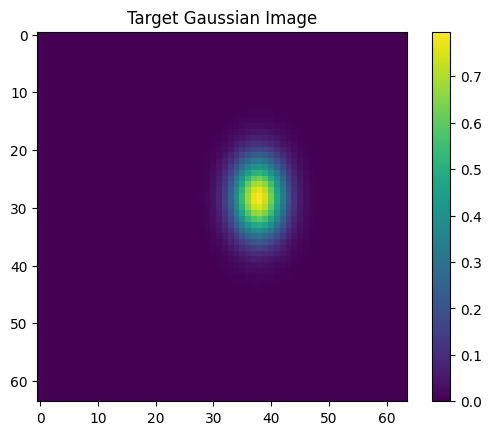

In [8]:
import matplotlib.pyplot as plt

plt.imshow(target_image.cpu().numpy())  # .numpy() transforms the PyTorch
                                        # tensor to a NumPy array.
                                        # .cpu() needed if using PyTorch
                                        # tensors on GPU.
plt.colorbar()
plt.title("Target Gaussian Image")
plt.show()

# 4. Performing the Optimization

Now prepare for the optimization:
1.  Define `sigma`, `mu`, and `amplitude` as `torch.nn.Parameter`. This tells PyTorch that these are tensors whose values you want to optimize. You can initialize them with arbitrary starting values.

In [9]:
import torch

# Define trainable parameters with initial guesses.
sigma = torch.nn.Parameter(torch.tensor([0.1, 0.1]))
mu = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
amplitude = torch.nn.Parameter(torch.tensor(1.0))

2.  Create a new `training_feature` pipeline, similar to the one used for the target image, but this time passing the trainable `torch.nn.Parameter` objects as arguments. DeepTrack2 automatically handles these parameters within the pipeline.

In [10]:
# Create the training pipeline using the trainable parameters.
training_feature = Grid2d() >> Gaussian2d(
    sigma=sigma,
    mu=mu,
    amplitude=amplitude,
)

3.  Instantiate a PyTorch optimizer (`Adam` in this case), passing the parameters we want it to train.

In [11]:
# Define the optimizer.
optimizer = torch.optim.Adam(
    [sigma, mu, amplitude],  # List of parameters to optimize
    lr=0.01,  # Learning rate
)

4. Finally, implement and execute the core optimization loop. 
    
    In each iteration, the trainign loop performs the followign steps:
    1.  `training_feature.update()()` calls the training pipeline. `.update()` ensures any internal state is refreshed (important since the change in parameters does not automatically invalidate the graph), and `()` executes the pipeline. This generates an image using the *current* values of `sigma`, `mu`, and `amplitude`.
    2.  `torch.nn.functional.mse_loss` calculates the Mean Squared Error (MSE) between the currently generated image and the `target_image`. This is your loss function.
    3.  `optimizer.zero_grad()` clears any gradients accumulated from previous iterations.
    4.  `loss.backward()` computes the gradients of the loss with respect to all trainable parameters (`sigma`, `mu`, `amplitude`). PyTorch tracks the operations and automatically calculates these gradients.
    5.  `optimizer.step()` updates the values of the parameters based on the computed gradients and the optimizer's algorithm (Adam).
    6.  It stores and prints the loss periodically to monitor progress.

In [12]:
losses = []

num_iterations = 100

for i in range(num_iterations):
    
    # Generate image with current parameters.
    image = training_feature.update()()

    # Calculate loss.
    loss = torch.nn.functional.mse_loss(image, target_image)

    # Backpropagation and optimization step.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Logging.
    losses.append(loss.item())
    if i % 10 == 0:
        # .data is used to access the tensor data without gradient tracking
        print(
            f"Iteration {i}/{num_iterations}, Loss: {loss.item():.4f}, "
            f"sigma: [{sigma.data[0]:.3f}, {sigma.data[1]:.3f}], "
            f"mu: [{mu.data[0]:.3f}, {mu.data[1]:.3f}], "
            f"amplitude: {amplitude.data:.3f}"
        )

Iteration 0/100, Loss: 0.0104, sigma: [0.090, 0.090], mu: [0.010, -0.010], amplitude: 0.990
Iteration 10/100, Loss: 0.0049, sigma: [0.127, 0.049], mu: [0.106, -0.101], amplitude: 0.910
Iteration 20/100, Loss: 0.0006, sigma: [0.119, 0.124], mu: [0.192, -0.108], amplitude: 0.853
Iteration 30/100, Loss: 0.0004, sigma: [0.087, 0.172], mu: [0.224, -0.088], amplitude: 0.812
Iteration 40/100, Loss: 0.0001, sigma: [0.100, 0.169], mu: [0.195, -0.105], amplitude: 0.774
Iteration 50/100, Loss: 0.0000, sigma: [0.103, 0.151], mu: [0.193, -0.100], amplitude: 0.750
Iteration 60/100, Loss: 0.0000, sigma: [0.106, 0.148], mu: [0.204, -0.099], amplitude: 0.758
Iteration 70/100, Loss: 0.0000, sigma: [0.101, 0.153], mu: [0.201, -0.101], amplitude: 0.777
Iteration 80/100, Loss: 0.0000, sigma: [0.099, 0.153], mu: [0.198, -0.099], amplitude: 0.791
Iteration 90/100, Loss: 0.0000, sigma: [0.101, 0.150], mu: [0.201, -0.101], amplitude: 0.797


Plotting the recorded loss values shows how the error decreased over the training iterations, indicating that the optimization converged.

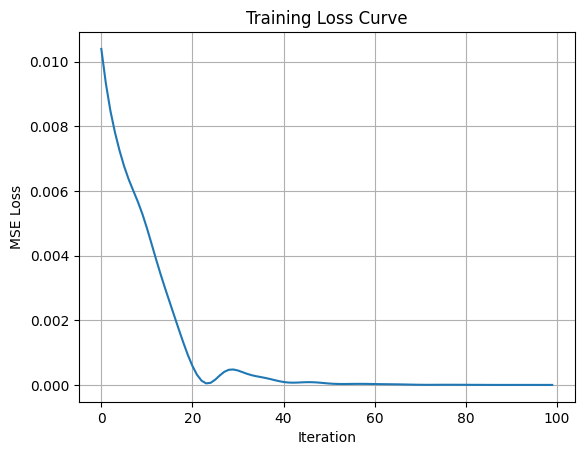

In [13]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


## 5. Evaluating the Result

Finally, you can compare the image generated with the final optimized parameters to the original target image.

1. Ensure to be working with NumPy arrays on the CPU for plotting for the target image using `cpu().detach().numpy()`.

In [14]:
import numpy as np

target_np = target_image.cpu().detach().numpy()

2. Get the final image from the trained pipeline with `training_feature.update()()` and ensure also this is transformed into a NumPy array on CPU.

In [15]:
training_np = training_feature.update()().cpu().detach().numpy()

3.  Display the final image obtained after training and the difference image (target - trained) highlighting areas where the fit isn't perfect.

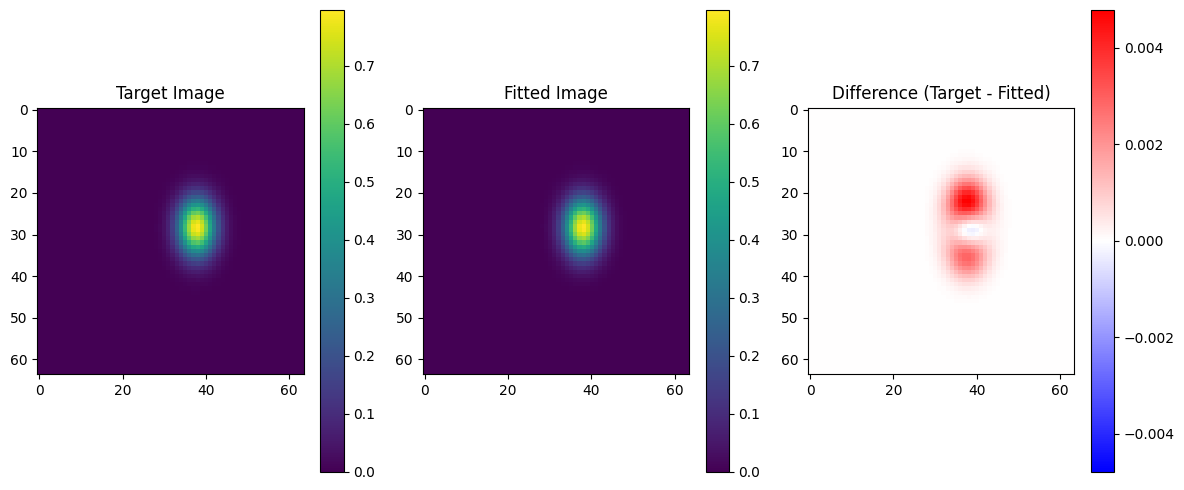

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(target_np)
plt.colorbar()
plt.title("Target Image")

plt.subplot(1, 3, 2)
plt.imshow(training_np)
plt.colorbar()
plt.title("Fitted Image")

plt.subplot(1, 3, 3)
difference = target_np - training_np
vmax = np.max(np.abs(difference))
plt.imshow(difference, cmap="bwr", vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.title("Difference (Target - Fitted)")

plt.tight_layout()
plt.show()

4. Print out the values of the optimized parameters.

In [17]:
print("\nFinal Optimized Parameters:")
print(f"Target sigma:      ({target_sigma[0]:.3f}, {target_sigma[1]:.3f})")
print(f"Fitted sigma:      [{sigma.data[0]:.3f}, {sigma.data[1]:.3f}]")
print(f"Target mu:         ({target_mu[0]:.3f}, {target_mu[1]:.3f})")
print(f"Fitted mu:         [{mu.data[0]:.3f}, {mu.data[1]:.3f}]")
print(f"Target amplitude:  {target_amplitude:.3f}")
print(f"Fitted amplitude:  {amplitude.data:.3f}")


Final Optimized Parameters:
Target sigma:      (0.100, 0.150)
Fitted sigma:      [0.100, 0.149]
Target mu:         (0.200, -0.100)
Fitted mu:         [0.200, -0.100]
Target amplitude:  0.800
Fitted amplitude:  0.800
